# Dupor (2023) household: minimal demo

Solve and simulate the infinite-horizon, separable-utility, Markov-income household,
then plot the ergodic cross-section of market resources, consumption, and labor supply.

In [4]:
import os, sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("dupor_minimal_demo.ipynb")) or os.getcwd()

# Make sure HARK's internal `from interpolation import interp` doesn't get
# shadowed by the local `interpolation.py` in this folder.
sys.path = [p for p in sys.path if os.path.abspath(p) != os.path.abspath(HERE)]

def _load_local(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_load_local("rewards", os.path.join(HERE, "rewards.py"))
cl = _load_local("ConsLaborModelSep", os.path.join(HERE, "ConsLaborModel copy.py"))
LaborIntMargSepMrkvConsumerType = cl.LaborIntMargSepMrkvConsumerType

In [5]:
agent = LaborIntMargSepMrkvConsumerType(cycles=0, T_cycle=1, D = 1, )
agent.solve()

agent.AgentCount = 5000
agent.T_sim = 500
agent.initialize_sim()
agent.simulate()

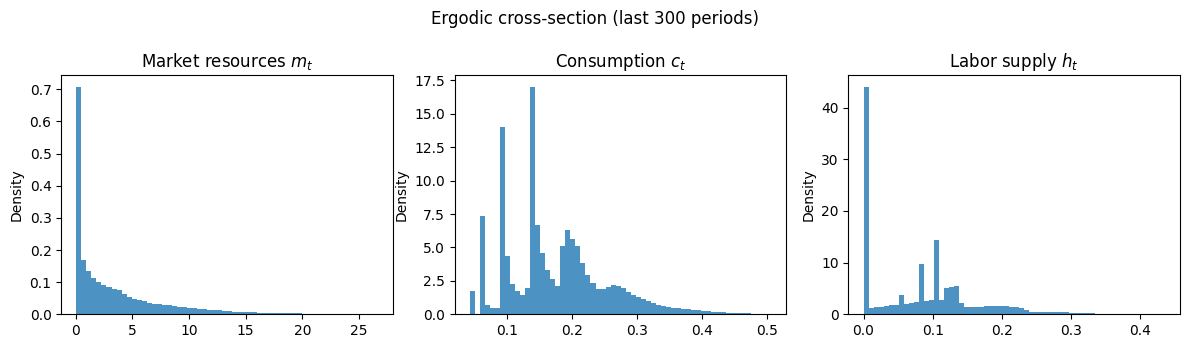

In [6]:
burn_in = 200
mLvl = agent.history["mLvl"][burn_in:, :].ravel()
cLvl = agent.history["cLvl"][burn_in:, :].ravel()
Lbr  = agent.history["Lbr"][burn_in:, :].ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, data, name in zip(
    axes,
    [mLvl, cLvl, Lbr],
    [r"Market resources $m_t$", r"Consumption $c_t$", r"Labor supply $h_t$"],
):
    ax.hist(data, bins=60, density=True, alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("Density")
fig.suptitle("Ergodic cross-section (last {} periods)".format(agent.T_sim - burn_in))
fig.tight_layout()
plt.show()